In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#generate Dataset (50 samples)
np.random.seed(42)
n_samples=50
data=pd.DataFrame({
    'Soil_Nitrogen':np.random.normal(70,10,n_samples),
    'Rainfall':np.random.normal(600,100,n_samples),
    'Temperature':np.random.normal(25,5,n_samples),
    'Water_usage':np.random.normal(400,80,n_samples)
})
#create classification Label(Healthy=1,Unhealthy=0)
data['Label']=(
    (data['Soil_Nitrogen']>65)&
    (data['Rainfall']>550)&
    (data['Water_usage']>350)
).astype(int)
print("Sample Data:\n",data.head())

Sample Data:
    Soil_Nitrogen    Rainfall  Temperature  Water_usage  Label
0      74.967142  632.408397    17.923146   420.039428      1
1      68.617357  561.491772    22.896773   427.715857      1
2      76.476885  532.307800    23.286427   345.598022      0
3      85.230299  661.167629    20.988614   418.580296      1
4      67.658466  703.099952    24.193571   423.445798      1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4750 - loss: 0.7301
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5500 - loss: 0.7171
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5750 - loss: 0.7075
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5750 - loss: 0.7003
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6250 - loss: 0.6890
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6250 - loss: 0.6811
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6250 - loss: 0.6718 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6750 - loss: 0.6638
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6500 - loss: 0.6541
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6500 - loss: 0.6468
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6500 - loss: 0.6390
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6500 - loss: 0.6308


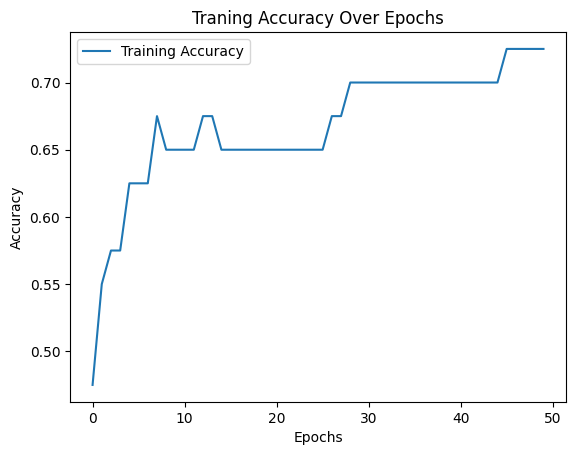

In [ ]:
# Separate features (X) and target (y)
X = data.drop('Label', axis=1)
y = data['Label']

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Feature scalling
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
#build ANN Model
model=Sequential()
#Input+Hidden Layers
model.add(Dense(8,activation='relu',input_dim=x_train.shape[1]))
model.add(Dense(6,activation='relu'))
#Output Layer
model.add(Dense(1,activation='sigmoid'))
#compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])
#train model
history=model.fit(
    x_train_scaled,y_train,
    epochs=50,
    batch_size=5,
    verbose=1
)
#predictions
y_pred=model.predict(x_test_scaled)
y_pred=(y_pred>0.5).astype(int)

#evaluation metrix
print("\n---Model Evaluation---")
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))
#plot training performance
plt.figure()
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Traning Accuracy Over Epochs")
plt.legend()
plt.show()